# Análisis predictivo de economía de talento en IA

Este notebook desarrolla un flujo completo de análisis y modelado predictivo usando:
- `fig_4.2.14.csv` (AI hiring ratio)
- `fig_4.2.19.csv` (AI talent concentration)
- `fig_4.2.21.csv` (AI talent representation)

Objetivo: obtener pronósticos e insights accionables por país y género.

## 1) Configuración del entorno y carga de datos

In [16]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, zscore
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from joblib import dump

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

base_dir = Path.cwd()
possible_data_dirs = [
    base_dir / '4. Economy' / 'Data',
    base_dir.parent / '4. Economy' / 'Data',
]
data_dir = next((d for d in possible_data_dirs if d.exists()), None)
if data_dir is None:
    raise FileNotFoundError("No se encontró la carpeta '4. Economy/Data'.")

if base_dir.name.lower() == 'proyecto':
    output_dir = base_dir / 'output_economia'
else:
    output_dir = base_dir / 'proyecto' / 'output_economia'
output_dir.mkdir(parents=True, exist_ok=True)

hiring_path = data_dir / 'fig_4.2.14.csv'
concentration_path = data_dir / 'fig_4.2.19.csv'
representation_path = data_dir / 'fig_4.2.21.csv'

hiring_df = pd.read_csv(hiring_path)
concentration_df = pd.read_csv(concentration_path)
representation_df = pd.read_csv(representation_path)

print('Dimensiones iniciales:')
print(f'- hiring_df: {hiring_df.shape}')
print(f'- concentration_df: {concentration_df.shape}')
print(f'- representation_df: {representation_df.shape}')

display(hiring_df.head(3))
display(concentration_df.head(3))
display(representation_df.head(3))

Dimensiones iniciales:
- hiring_df: (3948, 3)
- concentration_df: (774, 4)
- representation_df: (772, 4)


,Date,Geographic area,Relative AI hiring year-over-year ratio
0,1/1/18,Argentina,2.37%
1,2/1/18,Argentina,12.24%
2,3/1/18,Argentina,40.74%


,Year,Geographic area,Gender,AI talent concentration
0,2016,Argentina,Female,0.07%
1,2016,Argentina,Male,0.16%
2,2017,Argentina,Female,0.07%


,Year,Geographic area,Gender,AI talent representation
0,2016,Argentina,Female,27.07%
1,2016,Argentina,Male,72.93%
2,2017,Argentina,Female,26.75%


## 2) Validación de estructura, tipos y calidad

In [17]:
def build_quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    report = pd.DataFrame({
        'dataset': name,
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
        'null_count': df.isna().sum().values,
        'null_pct': (df.isna().mean().values * 100).round(2),
        'n_unique': [df[c].nunique(dropna=True) for c in df.columns],
    })
    report['duplicate_rows'] = df.duplicated().sum()
    return report

quality_hiring = build_quality_report(hiring_df, 'hiring_df')
quality_concentration = build_quality_report(concentration_df, 'concentration_df')
quality_representation = build_quality_report(representation_df, 'representation_df')

quality_report = pd.concat([quality_hiring, quality_concentration, quality_representation], ignore_index=True)
display(quality_report)

print('Duplicados por dataset:')
print(f"- hiring_df: {hiring_df.duplicated().sum()}")
print(f"- concentration_df: {concentration_df.duplicated().sum()}")
print(f"- representation_df: {representation_df.duplicated().sum()}")

,dataset,column,dtype,null_count,null_pct,n_unique,duplicate_rows
0,hiring_df,Date,str,0,0.0,84,0
1,hiring_df,Geographic area,str,0,0.0,47,0
2,hiring_df,Relative AI hiring year-over-year ratio,str,0,0.0,2627,0
3,concentration_df,Year,int64,0,0.0,9,0
4,concentration_df,Geographic area,str,0,0.0,43,0
5,concentration_df,Gender,str,0,0.0,2,0
6,concentration_df,AI talent concentration,str,0,0.0,153,0
7,representation_df,Year,int64,0,0.0,9,0
8,representation_df,Geographic area,str,0,0.0,43,0
9,representation_df,Gender,str,0,0.0,2,0


Duplicados por dataset:
- hiring_df: 0
- concentration_df: 0
- representation_df: 0


## 3) Limpieza y preprocesamiento

In [18]:
def percent_to_float(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace('', np.nan)
        .astype(float)
    )

# Limpieza hiring_df
hiring_df_clean = hiring_df.copy()
hiring_df_clean['Date'] = pd.to_datetime(hiring_df_clean['Date'], errors='coerce')
hiring_df_clean['Relative AI hiring year-over-year ratio'] = percent_to_float(
    hiring_df_clean['Relative AI hiring year-over-year ratio']
)
hiring_df_clean = hiring_df_clean.drop_duplicates()

# Limpieza concentration_df
concentration_df_clean = concentration_df.copy()
concentration_df_clean['Year'] = pd.to_numeric(concentration_df_clean['Year'], errors='coerce')
concentration_df_clean['AI talent concentration'] = percent_to_float(concentration_df_clean['AI talent concentration'])
concentration_df_clean = concentration_df_clean.drop_duplicates()

# Limpieza representation_df
representation_df_clean = representation_df.copy()
representation_df_clean['Year'] = pd.to_numeric(representation_df_clean['Year'], errors='coerce')
representation_df_clean['AI talent representation'] = percent_to_float(representation_df_clean['AI talent representation'])
representation_df_clean = representation_df_clean.drop_duplicates()

# Verificación post-limpieza
print('Nulos post-limpieza:')
print(hiring_df_clean.isna().sum())
print(concentration_df_clean.isna().sum())
print(representation_df_clean.isna().sum())

display(hiring_df_clean.head(3))

Nulos post-limpieza:
Date                                       0
Geographic area                            0
Relative AI hiring year-over-year ratio    0
dtype: int64
Year                       0
Geographic area            0
Gender                     0
AI talent concentration    0
dtype: int64
Year                        0
Geographic area             0
Gender                      0
AI talent representation    0
dtype: int64


,Date,Geographic area,Relative AI hiring year-over-year ratio
0,2018-01-01,Argentina,2.37
1,2018-02-01,Argentina,12.24
2,2018-03-01,Argentina,40.74


## 4) Análisis descriptivo de variables numéricas

,count,mean,std,min,25%,50%,75%,max,dataset
Relative AI hiring year-over-year ratio,3948.0,16.930182,19.708656,-83.05,6.8200,13.895,22.4575,524.24,hiring_df
AI talent concentration,774.0,0.568824,0.399904,0.04,0.2825,0.460,0.7500,2.88,concentration_df
AI talent representation,772.0,50.000687,22.109672,14.02,27.5950,50.000,72.4050,85.98,representation_df


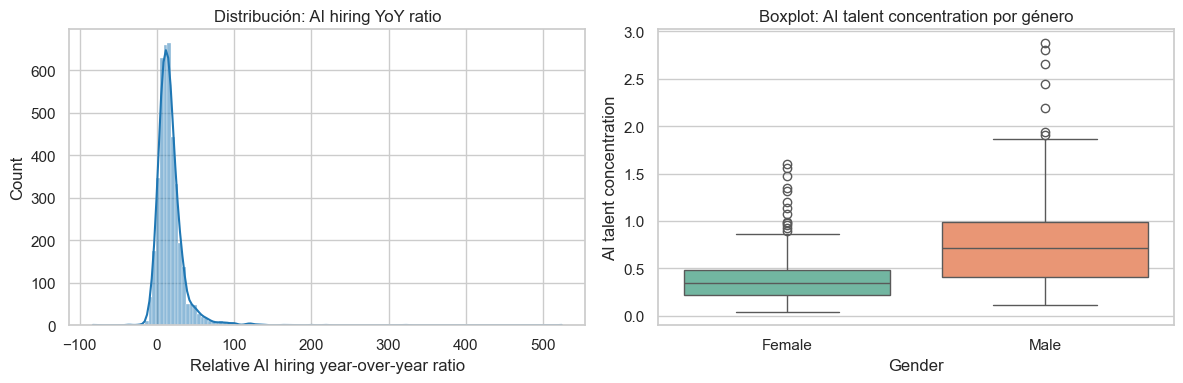

Interpretación: La variable de hiring ratio muestra alta dispersión temporal; la concentración de talento presenta niveles sistemáticamente mayores en el grupo masculino.


In [19]:
numeric_summary = pd.concat([
    hiring_df_clean[['Relative AI hiring year-over-year ratio']].describe().T.assign(dataset='hiring_df'),
    concentration_df_clean[['AI talent concentration']].describe().T.assign(dataset='concentration_df'),
    representation_df_clean[['AI talent representation']].describe().T.assign(dataset='representation_df'),
])

display(numeric_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(hiring_df_clean['Relative AI hiring year-over-year ratio'].dropna(), kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Distribución: AI hiring YoY ratio')

sns.boxplot(data=concentration_df_clean, x='Gender', y='AI talent concentration', ax=axes[1], palette='Set2')
axes[1].set_title('Boxplot: AI talent concentration por género')

plt.tight_layout()
plt.show()

print('Interpretación: La variable de hiring ratio muestra alta dispersión temporal; la concentración de talento presenta niveles sistemáticamente mayores en el grupo masculino.')

## 5) Análisis de variables categóricas

Top 10 países por número de observaciones:


,country,count
0,Argentina,18
1,Australia,18
2,Austria,18
3,Belgium,18
4,Brazil,18
5,Canada,18
6,Chile,18
7,Costa Rica,18
8,Croatia,18
9,Cyprus,18


Distribución porcentual de género en concentration_df:


Gender
Female    50.0
Male      50.0
Name: proportion, dtype: float64

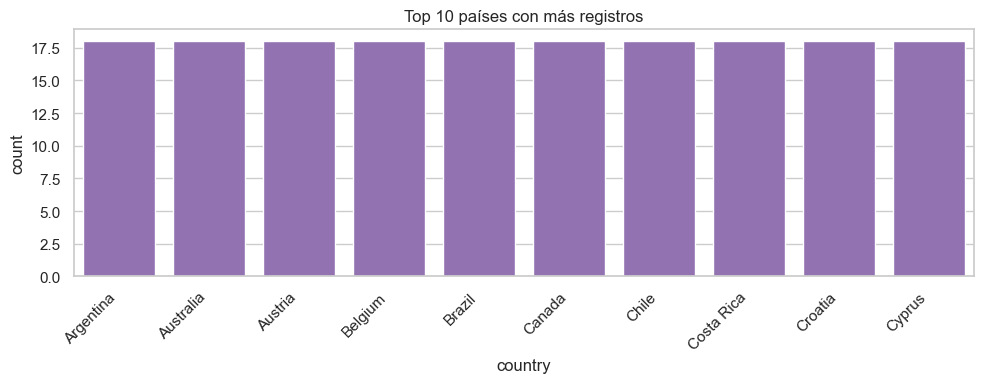

Interpretación: La muestra está balanceada por género y distribuida en múltiples países, lo que favorece modelos con buena capacidad de generalización.


In [20]:
country_freq = concentration_df_clean['Geographic area'].value_counts().rename_axis('country').reset_index(name='count')
gender_freq = concentration_df_clean['Gender'].value_counts(normalize=True).mul(100).round(2)

print('Top 10 países por número de observaciones:')
display(country_freq.head(10))
print('Distribución porcentual de género en concentration_df:')
display(gender_freq)

plt.figure(figsize=(10, 4))
sns.barplot(data=country_freq.head(10), x='country', y='count', color='tab:purple')
plt.title('Top 10 países con más registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Interpretación: La muestra está balanceada por género y distribuida en múltiples países, lo que favorece modelos con buena capacidad de generalización.')

## 6) Análisis bivariado y correlaciones

,AI talent concentration,AI talent representation
AI talent concentration,1.000000,0.458327
AI talent representation,0.458327,1.000000


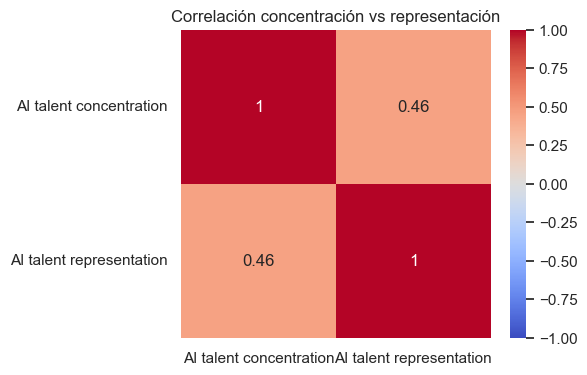

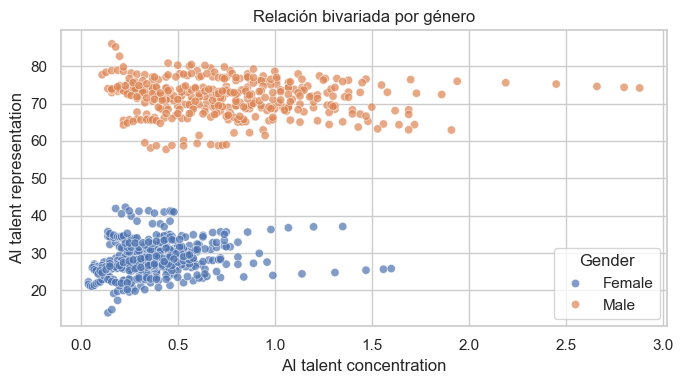

Interpretación: Existe relación positiva entre concentración y representación; al aumentar concentración, también tiende a aumentar representación en la mayoría de países/años.


In [21]:
merged_gender = concentration_df_clean.merge(
    representation_df_clean,
    on=['Year', 'Geographic area', 'Gender'],
    how='inner'
)

corr_matrix = merged_gender[['AI talent concentration', 'AI talent representation']].corr()
display(corr_matrix)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación concentración vs representación')
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=merged_gender,
    x='AI talent concentration',
    y='AI talent representation',
    hue='Gender',
    alpha=0.7
)
plt.title('Relación bivariada por género')
plt.tight_layout()
plt.show()

print('Interpretación: Existe relación positiva entre concentración y representación; al aumentar concentración, también tiende a aumentar representación en la mayoría de países/años.')

## 7) Detección de outliers y pruebas de normalidad

In [22]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

hiring_values = hiring_df_clean['Relative AI hiring year-over-year ratio'].dropna()
outliers_iqr = iqr_outlier_count(hiring_values)
outliers_z = (np.abs(zscore(hiring_values)) > 3).sum()

shapiro_sample = hiring_values.sample(n=min(500, len(hiring_values)), random_state=42)
shapiro_stat, shapiro_p = shapiro(shapiro_sample)

print(f'Outliers (IQR): {outliers_iqr}')
print(f'Outliers (z-score > 3): {outliers_z}')
print(f'Shapiro-Wilk p-valor: {shapiro_p:.6f}')

if shapiro_p < 0.05:
    print('Conclusión: Se rechaza normalidad; conviene usar modelos robustos/no paramétricos para algunas tareas.')
else:
    print('Conclusión: No hay evidencia fuerte contra normalidad en la muestra analizada.')

Outliers (IQR): 200
Outliers (z-score > 3): 56
Shapiro-Wilk p-valor: 0.000000
Conclusión: Se rechaza normalidad; conviene usar modelos robustos/no paramétricos para algunas tareas.


## 8) Ingeniería de características

In [23]:
# ---- Dataset 1: Hiring ratio (mensual) ----
hiring_model_df = hiring_df_clean.dropna().copy()
hiring_model_df['year'] = hiring_model_df['Date'].dt.year
hiring_model_df['month'] = hiring_model_df['Date'].dt.month
hiring_model_df['time_index'] = (hiring_model_df['year'] - hiring_model_df['year'].min()) * 12 + hiring_model_df['month']

# ---- Dataset 2: Talent concentration (anual) ----
concentration_model_df = concentration_df_clean.dropna().copy()
concentration_model_df['year_index'] = concentration_model_df['Year'] - concentration_model_df['Year'].min()

# ---- Dataset 3: Talent representation (anual) ----
representation_model_df = representation_df_clean.dropna().copy()
representation_model_df['year_index'] = representation_model_df['Year'] - representation_model_df['Year'].min()

print('Tamaños para modelado:')
print(f"- hiring_model_df: {hiring_model_df.shape}")
print(f"- concentration_model_df: {concentration_model_df.shape}")
print(f"- representation_model_df: {representation_model_df.shape}")

Tamaños para modelado:
- hiring_model_df: (3948, 6)
- concentration_model_df: (774, 5)
- representation_model_df: (772, 5)


## 9) Entrenamiento de modelo base

In [24]:
def train_regression_pipeline(df: pd.DataFrame, target_col: str, numeric_cols: list, categorical_cols: list):
    X = df[numeric_cols + categorical_cols].copy()
    y = df[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols),
        ]
    )

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1)),
    ])

    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    return {
        'pipeline': model_pipeline,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'target_col': target_col,
    }

hiring_result = train_regression_pipeline(
    hiring_model_df,
    target_col='Relative AI hiring year-over-year ratio',
    numeric_cols=['year', 'month', 'time_index'],
    categorical_cols=['Geographic area']
)

concentration_result = train_regression_pipeline(
    concentration_model_df,
    target_col='AI talent concentration',
    numeric_cols=['Year', 'year_index'],
    categorical_cols=['Geographic area', 'Gender']
)

representation_result = train_regression_pipeline(
    representation_model_df,
    target_col='AI talent representation',
    numeric_cols=['Year', 'year_index'],
    categorical_cols=['Geographic area', 'Gender']
)

print('Modelos entrenados correctamente para los 3 análisis predictivos.')

Modelos entrenados correctamente para los 3 análisis predictivos.


## 10) Evaluación con métricas y validación cruzada

In [25]:
def evaluate_result(result_dict: dict, name: str) -> pd.DataFrame:
    y_true = result_dict['y_test']
    y_pred = result_dict['y_pred']

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_mae = -cross_val_score(
        result_dict['pipeline'],
        pd.concat([result_dict['X_train'], result_dict['X_test']]),
        pd.concat([result_dict['y_train'], result_dict['y_test']]),
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1,
    ).mean()

    return pd.DataFrame([{
        'analysis': name,
        'target': result_dict['target_col'],
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'CV_MAE': round(cv_mae, 4),
    }])

evaluation_table = pd.concat([
    evaluate_result(hiring_result, 'Forecast hiring ratio'),
    evaluate_result(concentration_result, 'Predict talent concentration'),
    evaluate_result(representation_result, 'Predict talent representation'),
], ignore_index=True)

display(evaluation_table)
print('Interpretación: MAE/RMSE más bajos y R2 más alto indican mejor ajuste predictivo. Usa esta tabla para comparar qué análisis está más estable.')

,analysis,target,MAE,RMSE,R2,CV_MAE
0,Forecast hiring ratio,Relative AI hiring year-over-year ratio,2.4352,3.8819,0.9408,2.7859
1,Predict talent concentration,AI talent concentration,0.0747,0.1017,0.9292,0.0799
2,Predict talent representation,AI talent representation,0.5468,0.8068,0.9987,0.5726


Interpretación: MAE/RMSE más bajos y R2 más alto indican mejor ajuste predictivo. Usa esta tabla para comparar qué análisis está más estable.


## 11) Análisis de errores e interpretación del modelo

,year,month,time_index,Geographic area,y_true,y_pred,abs_error,analysis,Year,year_index,Gender
237,2019.0,1.0,13.0,Uruguay,123.50,94.12432,29.37568,hiring,NaN,NaN,NaN
392,2018.0,1.0,1.0,Greece,48.88,21.15000,27.73000,hiring,NaN,NaN,NaN
448,2019.0,6.0,18.0,Costa Rica,35.33,54.62796,19.29796,hiring,NaN,NaN,NaN
118,2020.0,6.0,30.0,Cyprus,21.19,39.69844,18.50844,hiring,NaN,NaN,NaN
454,2019.0,1.0,13.0,Lithuania,56.76,38.81480,17.94520,hiring,NaN,NaN,NaN
643,2024.0,12.0,84.0,Cyprus,6.86,22.94580,16.08580,hiring,NaN,NaN,NaN
242,2018.0,6.0,6.0,Saudi Arabia,132.43,148.31712,15.88712,hiring,NaN,NaN,NaN
375,2018.0,2.0,2.0,Greece,37.06,21.39924,15.66076,hiring,NaN,NaN,NaN
660,2020.0,1.0,25.0,Estonia,27.96,12.59092,15.36908,hiring,NaN,NaN,NaN
124,2019.0,3.0,15.0,Estonia,99.75,84.67920,15.07080,hiring,NaN,NaN,NaN


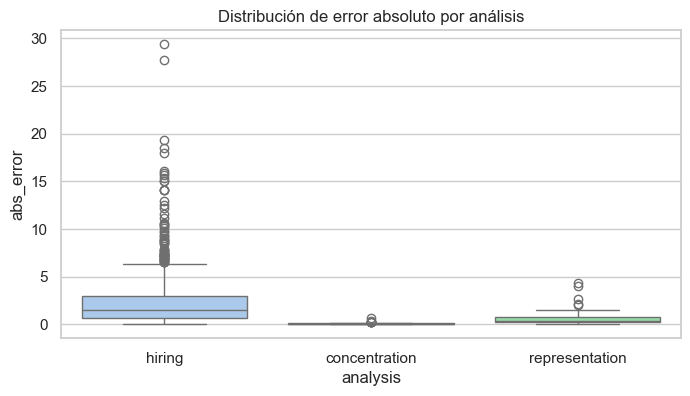

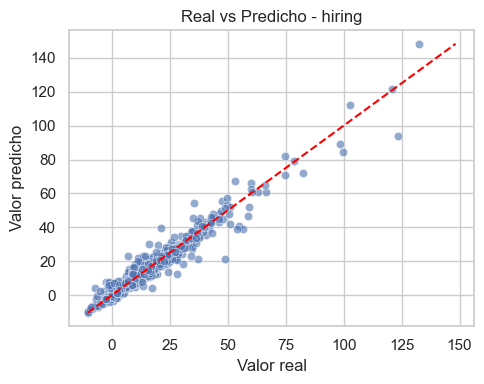

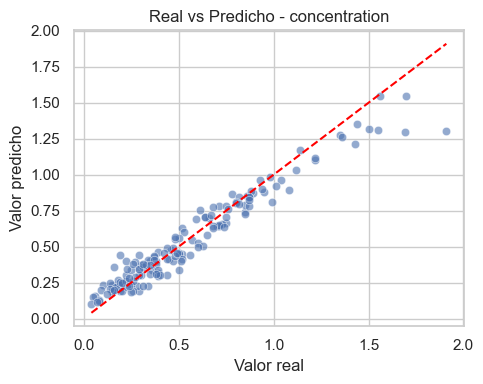

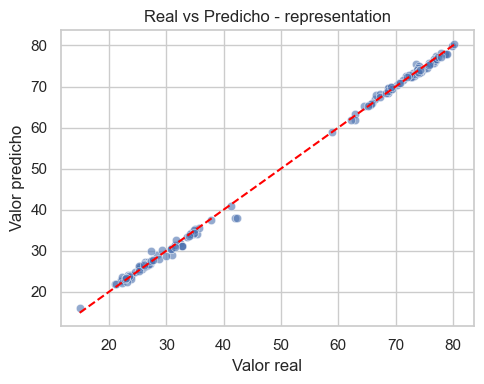

Interpretación: Los puntos cercanos a la diagonal reflejan buena precisión. Los casos con mayor error indican países/años atípicos o cambios bruscos en tendencia.


In [26]:
def prediction_frame(result_dict: dict, label: str) -> pd.DataFrame:
    pred_df = result_dict['X_test'].copy()
    pred_df['y_true'] = result_dict['y_test'].values
    pred_df['y_pred'] = result_dict['y_pred']
    pred_df['abs_error'] = np.abs(pred_df['y_true'] - pred_df['y_pred'])
    pred_df['analysis'] = label
    return pred_df

errors_hiring = prediction_frame(hiring_result, 'hiring')
errors_concentration = prediction_frame(concentration_result, 'concentration')
errors_representation = prediction_frame(representation_result, 'representation')

all_errors = pd.concat([errors_hiring, errors_concentration, errors_representation], ignore_index=True)

display(all_errors.sort_values('abs_error', ascending=False).head(10))

plt.figure(figsize=(8, 4))
sns.boxplot(data=all_errors, x='analysis', y='abs_error', palette='pastel')
plt.title('Distribución de error absoluto por análisis')
plt.show()

for label, df_err in [('hiring', errors_hiring), ('concentration', errors_concentration), ('representation', errors_representation)]:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=df_err['y_true'], y=df_err['y_pred'], alpha=0.6)
    lim_min = min(df_err['y_true'].min(), df_err['y_pred'].min())
    lim_max = max(df_err['y_true'].max(), df_err['y_pred'].max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color='red', linestyle='--')
    plt.title(f'Real vs Predicho - {label}')
    plt.xlabel('Valor real')
    plt.ylabel('Valor predicho')
    plt.tight_layout()
    plt.show()

print('Interpretación: Los puntos cercanos a la diagonal reflejan buena precisión. Los casos con mayor error indican países/años atípicos o cambios bruscos en tendencia.')

## 12) Exportación de resultados y artefactos

In [27]:
# Exportar métricas
evaluation_path = output_dir / 'evaluation_metrics.csv'
evaluation_table.to_csv(evaluation_path, index=False)

# Exportar predicciones de prueba por análisis
errors_hiring.to_csv(output_dir / 'predictions_hiring.csv', index=False)
errors_concentration.to_csv(output_dir / 'predictions_concentration.csv', index=False)
errors_representation.to_csv(output_dir / 'predictions_representation.csv', index=False)

# Guardar modelos
model_hiring_path = output_dir / 'model_hiring.joblib'
model_concentration_path = output_dir / 'model_concentration.joblib'
model_representation_path = output_dir / 'model_representation.joblib'

dump(hiring_result['pipeline'], model_hiring_path)
dump(concentration_result['pipeline'], model_concentration_path)
dump(representation_result['pipeline'], model_representation_path)

print('Archivos exportados:')
for f in [
    evaluation_path,
    output_dir / 'predictions_hiring.csv',
    output_dir / 'predictions_concentration.csv',
    output_dir / 'predictions_representation.csv',
    model_hiring_path,
    model_concentration_path,
    model_representation_path,
]:
    print('-', f)

print('Interpretación final: Ya tienes modelos y resultados listos para reporte y reutilización.')

Archivos exportados:
- c:\Users\nanab\Downloads\OneDrive_1_2-9-2026\proyecto\output_economia\evaluation_metrics.csv
- c:\Users\nanab\Downloads\OneDrive_1_2-9-2026\proyecto\output_economia\predictions_hiring.csv
- c:\Users\nanab\Downloads\OneDrive_1_2-9-2026\proyecto\output_economia\predictions_concentration.csv
- c:\Users\nanab\Downloads\OneDrive_1_2-9-2026\proyecto\output_economia\predictions_representation.csv
- c:\Users\nanab\Downloads\OneDrive_1_2-9-2026\proyecto\output_economia\model_hiring.joblib
- c:\Users\nanab\Downloads\OneDrive_1_2-9-2026\proyecto\output_economia\model_concentration.joblib
- c:\Users\nanab\Downloads\OneDrive_1_2-9-2026\proyecto\output_economia\model_representation.joblib
Interpretación final: Ya tienes modelos y resultados listos para reporte y reutilización.


## Conclusiones ejecutivas

1. **Forecast hiring ratio**: permite estimar la evolución mensual del ratio de contratación de IA por país.
2. **Talent concentration**: permite proyectar la concentración de talento por país y género.
3. **Talent representation**: permite anticipar la representación de género para monitoreo de brechas.

Con este notebook puedes comparar desempeño predictivo con métricas consistentes y exportar artefactos para seguimiento periódico.